In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../../src/")

## Model comparison

In this notebook, we will compare the performance of the best classifiers on "F1-macro avg" (using the optimal data balancing strategy) from each model family on the test set. The evaluation will be performed using 
+ ROC curves
+ Precision-Recall (PR) curves
+ Macro F1-Score to assess their effectiveness across different metrics and operating conditions

In [2]:
from classification_utility import train_test_for_non_distance_comp


_, _, _, test_labels = train_test_for_non_distance_comp()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


In the notebooks dedicated to classifiers, we first identified the best hyperparameters during the model selection phase—either through Grid Search cross-validation (CV) or manual split validation. Using these optimal configurations, each classifier was then retrained on the entire training dataset, and its performance was evaluated on the test set.

To speed up the comparison process, we saved the results to files. Now, we will load the results of the best-performing classifiers—one for each model family—based on the F1-Macro average score for further evaluation and analysis.

In [3]:
from classification_utility import load_classification_res


_, _, knn_smote_predicted_labels, knn_smote_probability_class_res = load_classification_res('knn_smote_sampling')
_, _, linear_svm_under_predicted_labels, linear_svm_under_probability_class_res = load_classification_res('linear_svm_under_sampling')
_, _, rbf_svm_under_predicted_labels, rbf_svm_under_probability_class_res = load_classification_res('rbf_svm_under_sampling')
_, _, ripper_under_predicted_labels, ripper_under_probability_class_res = load_classification_res('ripper_under_sampling')

_, _, dt_under_sampling_predicted_labels, results_dt_under_sampling = load_classification_res('dt_under_sampling')
_, _, rf_over_sampling_predicted_labels, results_rf_over_sampling = load_classification_res('rf_over_sampling')
_, _, abc_under_sampling_predicted_labels, results_abc_under_sampling = load_classification_res('ada_under_sampling')
_, _, gnb_smote_sampling_predicted_labels, results_gnb_smote_sampling = load_classification_res('gnb_smote_sampling')

_, _, nn_under_predicted_labels, nn_under_probability_class_res = load_classification_res('NN_under_sampling')

### ROC e PR curve comparison

In [4]:
curves = [
    (knn_smote_probability_class_res, "KNN SmoteOverSampling"),
    (linear_svm_under_probability_class_res, "Linear SVM RandUnderSampling"),
    (rbf_svm_under_probability_class_res, "Rfb SVM RandUnderSampling"),
    (ripper_under_probability_class_res, "Ripper RandUnderSampling"),
    (results_dt_under_sampling, "DT RandUnderSampling"),
    (results_rf_over_sampling, "RF RandOverSampling"),
    (results_abc_under_sampling, "ADABoost RandUnderSampling"),
    (results_gnb_smote_sampling, "GNB SmoteOverSampling"),
    (nn_under_probability_class_res, "NN RandUnderSampling")
]

<Figure size 640x480 with 0 Axes>

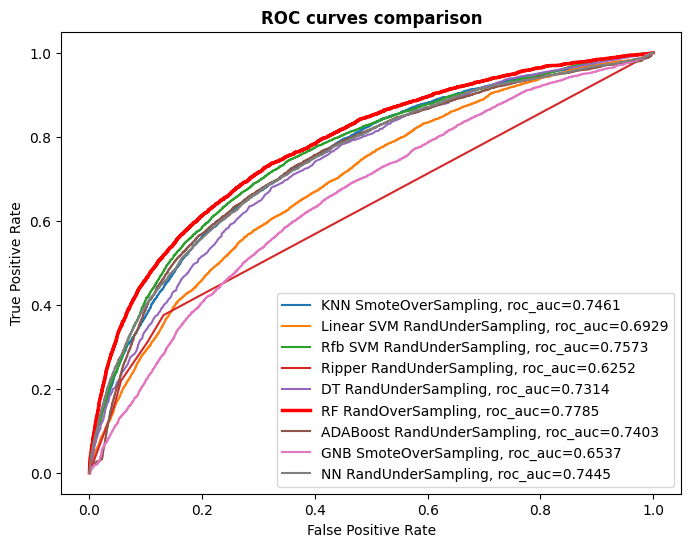

In [5]:
from classification_utility import compare_roc_curves

compare_roc_curves(curves, title="ROC curves comparison", figsize=(8, 6))

The ROC curves comparison indicates that the Random Forest (RF) model outperforms all
other methods, as it achieves the highest AUC (0.7785) and its curve consistently lies above the others
across all operating points. This demonstrates that it is the best model in this context, regardless of the
specific requirements on TPR and FPR.
However, the same reasoning cannot be applied in the comparison of models such as KNN and RBF SVM.
Despite RBF SVM having a slightly higher AUC (0.7573) compared to KNN (0.7461), their curves cross at
certain operating points. This implies that KNN may outperform RBF SVM in specific ranges, particularly
between 0.6–0.8 FPR, making the choice of the better model dependent on the application’s requirements
and the desired trade-off between False Positive Rate (FPR) and True Positive Rate (TPR)
The same reasoning applies to other comparisons, unless the operational curve of one method completely
dominates the other. Only in such cases, the superior model should always be preferred— another example
is the Neural Network (NN) consistently outperforming Linear SVM, making it the better choice in any
scenario.

<Figure size 640x480 with 0 Axes>

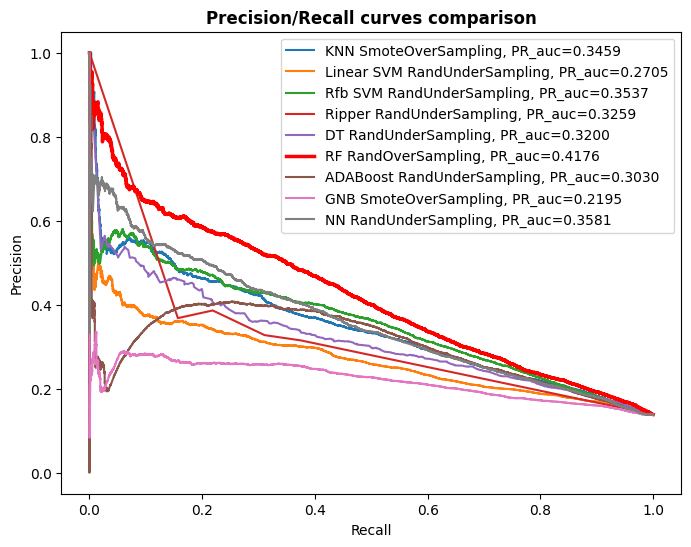

In [6]:
from classification_utility import compare_pr_curves

compare_pr_curves(curves, title="Precision/Recall curves comparison", figsize=(8, 6))

The Precision-Recall (PR) curves illustrate the trade-offs between precision
and recall at different thresholds. At the highest probability threshold, represented by the points at the far
right of the graph, all models converge to a value determined by the ratio of positives (P) to total samples
(P + N).
Similar to the ROC analysis, the evaluation of these curves must consider not only the AUC-PR but also the
specific operating points (pairs of precision and recall) relevant to the problem’s requirements. Depending
on the desired balance between precision and recall, the selection of the most suitable model may vary
across different thresholds. For example, if the objective is to maximize precision within specific recall
ranges, Neural Networks (NN) outperform RBF SVM in the approximately 0.1–0.3 recall range. Therefore,
if the requirements on recall fall within this range, NN would be a better choice compared to RBF SVM.

### F1 macro model comparison

In [7]:
class ModelInfo:
    def __init__(self, name):
        self.name = name

In [8]:
from classification_utility import compare_f1_score

test_predictions = [
    (knn_smote_predicted_labels, ModelInfo("KNN SmoteOverSampling")),
    (linear_svm_under_predicted_labels, ModelInfo("Linear SVM RandUnderSampling")),
    (rbf_svm_under_predicted_labels, ModelInfo("Rfb SVM RandUnderSampling")),
    (ripper_under_predicted_labels, ModelInfo("Ripper RandUnderSampling")),
    (dt_under_sampling_predicted_labels, ModelInfo("DT RandUnderSampling")),
    (rf_over_sampling_predicted_labels, ModelInfo("RF RandOverSampling")),
    (abc_under_sampling_predicted_labels, ModelInfo("ADABoost RandUnderSampling")),
    (gnb_smote_sampling_predicted_labels, ModelInfo("GNB SmoteOverSampling")),
    (nn_under_predicted_labels, ModelInfo("NN RandUnderSampling"))
]
model_infos = [model_info for _, model_info in test_predictions]
model_predictions = [predictions for predictions, _ in test_predictions]
compare_f1_score(model_infos, model_predictions, test_labels)

,Model,Macro F1-Score
5,RF RandOverSampling,0.675041
2,Rfb SVM RandUnderSampling,0.640850
8,NN RandUnderSampling,0.638565
0,KNN SmoteOverSampling,0.637014
6,ADABoost RandUnderSampling,0.618663
4,DT RandUnderSampling,0.618055
3,Ripper RandUnderSampling,0.612331
1,Linear SVM RandUnderSampling,0.591383
7,GNB SmoteOverSampling,0.575733


The Random Forest model trained with random oversampling achieves the best performance, with a Macro F1-Score of 0.675041. Other models, such as Rbf SVM with undersampling (0.640850) and Neural Networks with undersampling (0.638565), also perform competitively but remain slightly behind.

On the lower end, we observed that Linear SVM (0.591383) and Gaussian Naive Bayes (0.575733) yielded lower scores, which aligns with expectations. The Linear SVM likely struggled due to its simplistic linear decision boundaries, which may be insufficient for capturing complex patterns in the dataset. Similarly, the GNB model assumes that features are conditionally independent and normally distributed, assumptions that are unlikely to hold in this dataset.